In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import CONSTANT as cons

In [3]:
spectrogram_id = 789577333  # from train.csv, column "spectrogram_id"
spec1 = pd.read_parquet(f"{cons.PATH_TO_FILES_TRAIN_SPECT}/{spectrogram_id}.parquet")

In [4]:
print(f"Shape: {spec1.shape}")
print(f"  -> {spec1.shape[0]} rows (time windows)")
print(f"  -> {spec1.shape[1]} columns (1 time + region/frequency pairs)")
print(f"\nFirst 8 columns: {list(spec1.columns[:8])}")
print(f"Last 5 columns:  {list(spec1.columns[-5:])}")

Shape: (308, 401)
  -> 308 rows (time windows)
  -> 401 columns (1 time + region/frequency pairs)

First 8 columns: ['time', 'LL_0.59', 'LL_0.78', 'LL_0.98', 'LL_1.17', 'LL_1.37', 'LL_1.56', 'LL_1.76']
Last 5 columns:  ['RP_19.14', 'RP_19.34', 'RP_19.53', 'RP_19.73', 'RP_19.92']


In [5]:
spec_cols = [c for c in spec1.columns if c != 'time']

regions = sorted(set(c.split('_')[0] for c in spec_cols))
frequencies = sorted(set(float(c.split('_')[1]) for c in spec_cols))

print(f"Brain regions ({len(regions)}): {regions}")
print(f"Number of frequency bins per region: {len(frequencies)}")
print(f"Frequency range: {min(frequencies):.2f} Hz to {max(frequencies):.2f} Hz")
print(f"Frequency resolution: ~{frequencies[1] - frequencies[0]:.4f} Hz between bins")
print(f"\nSanity check: {len(regions)} regions x {len(frequencies)} freqs = {len(regions)*len(frequencies)} cols")
print(f"Actual non-time columns: {len(spec_cols)}")

Brain regions (4): ['LL', 'LP', 'RL', 'RP']
Number of frequency bins per region: 100
Frequency range: 0.59 Hz to 19.92 Hz
Frequency resolution: ~0.1900 Hz between bins

Sanity check: 4 regions x 100 freqs = 400 cols
Actual non-time columns: 400


In [6]:
print(f"Time column dtype: {spec1['time'].dtype}")
print(f"Time values: starts at {spec1['time'].iloc[0]}, ends at {spec1['time'].iloc[-1]}")
print(f"Spacing between rows: {spec1['time'].diff().dropna().unique()} seconds")

duration_seconds = spec1['time'].iloc[-1] - spec1['time'].iloc[0]
duration_minutes = duration_seconds / 60
print(f"\nTotal recording duration: {duration_seconds} seconds ({duration_minutes:.1f} minutes)")
print(f"Number of time windows: {len(spec1)}")
print(f"Time resolution: 1 row per {spec1['time'].diff().median()} seconds")

Time column dtype: int64
Time values: starts at 1, ends at 615
Spacing between rows: [2.] seconds

Total recording duration: 614 seconds (10.2 minutes)
Number of time windows: 308
Time resolution: 1 row per 2.0 seconds


In [7]:
spec1.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Columns: 401 entries, time to RP_19.92
dtypes: float32(400), int64(1)
memory usage: 483.8 KB


In [8]:
print("First 3 rows, first 6 columns:")
display(spec1.iloc[:3, :6])

print("\nRandom 3 rows, sampling 6 columns from across the spectrum:")
sample_cols = ['time'] + spec_cols[::80]  # every 80th column
display(spec1[sample_cols].sample(3, random_state=42))

First 3 rows, first 6 columns:


,time,LL_0.59,LL_0.78,LL_0.98,LL_1.17,LL_1.37
0,1,180.660004,211.250000,209.270004,159.089996,113.300003
1,3,134.839996,210.960007,272.209991,206.259995,187.899994
2,5,94.389999,130.330002,138.309998,159.229996,132.679993



Random 3 rows, sampling 6 columns from across the spectrum:


,time,LL_0.59,LL_16.21,RL_12.3,LP_8.4,RP_4.49
288,577,322.730011,0.44,6.03,8.62,76.199997
9,19,282.510010,0.33,0.82,9.72,64.169998
57,115,91.529999,0.23,0.31,8.27,23.410000


In [9]:
display(spec1.describe().T.head(10))   # first 10 (mostly LL low-freq)
display(spec1.describe().T.tail(10))   # last 10 (mostly RP high-freq)

,count,mean,std,min,25%,50%,75%,max
time,308.0,308.000000,178.112324,1.000000,154.500000,308.000000,461.500000,615.000000
LL_0.59,308.0,315.182922,1288.438354,39.259998,113.299997,178.910004,275.542503,16808.089844
LL_0.78,308.0,412.705292,1566.025269,39.740002,149.750000,241.224998,368.369995,19816.980469
LL_0.98,308.0,461.808960,1605.516357,63.400002,178.230000,278.485001,445.127502,20740.460938
LL_1.17,308.0,433.050323,1235.631470,61.630001,180.500004,279.650009,434.442497,15757.110352
LL_1.37,308.0,360.698883,914.344604,43.549999,160.777504,248.994995,355.007507,11872.879883
LL_1.56,308.0,287.353149,689.618225,36.439999,126.417501,191.065002,295.180008,8908.549805
LL_1.76,308.0,231.069901,541.755188,27.520000,104.512501,154.125000,237.739998,6950.069824
LL_1.95,308.0,182.562164,423.294312,18.510000,88.552500,126.040001,181.605003,5310.080078
LL_2.15,308.0,148.900665,365.485199,29.469999,78.167500,108.685001,141.630001,4788.890137


,count,mean,std,min,25%,50%,75%,max
RP_18.16,308.0,6.560747,54.129555,0.11,0.3600,0.715,2.1150,688.390015
RP_18.36,308.0,6.288085,51.983566,0.11,0.3400,0.640,2.0225,658.429993
RP_18.55,308.0,6.159967,50.394028,0.11,0.3275,0.620,1.9725,635.539978
RP_18.75,308.0,6.090097,49.794361,0.11,0.3000,0.575,1.8050,628.020020
RP_18.95,308.0,6.042857,49.451530,0.08,0.2900,0.525,1.9450,629.719971
RP_19.14,308.0,5.954481,48.654366,0.09,0.2800,0.485,2.0325,626.849976
RP_19.34,308.0,5.826720,47.414810,0.08,0.2700,0.480,1.8325,609.750000
RP_19.53,308.0,5.698312,46.646336,0.10,0.2700,0.470,2.0475,598.270020
RP_19.73,308.0,5.463019,44.586666,0.11,0.2700,0.470,1.8825,559.200012
RP_19.92,308.0,5.306526,43.407734,0.10,0.2800,0.470,1.7975,547.330017


In [10]:
bands = {
    'delta (0.5-4 Hz)':  (0.5, 4),
    'theta (4-8 Hz)':    (4, 8),
    'alpha (8-13 Hz)':   (8, 13),
    'beta  (13-30 Hz)':  (13, 30),
}

summary = []
for region in regions:
    for band_name, (lo, hi) in bands.items():
        cols_in_band = [c for c in spec_cols
                        if c.startswith(region + '_')
                        and lo <= float(c.split('_')[1]) < hi]
        if cols_in_band:
            mean_power = spec1[cols_in_band].values.mean()
            summary.append({'region': region, 'band': band_name, 'mean_power': mean_power})

import pandas as pd
band_summary = pd.DataFrame(summary).pivot(index='region', columns='band', values='mean_power')
display(band_summary.round(2))

band,alpha (8-13 Hz),beta (13-30 Hz),delta (0.5-4 Hz),theta (4-8 Hz)
region,,,,
LL,5.190000,1.47,193.860001,26.040001
LP,11.860000,3.29,254.779999,37.180000
RL,8.820000,2.74,351.989990,40.560001
RP,24.809999,8.94,824.260010,84.180000


In [11]:
missing = spec1.isna().sum()
print(f"Total NaN cells: {missing.sum()}")
print(f"Columns with any NaN: {(missing > 0).sum()} out of {len(spec1.columns)}")

if missing.sum() > 0:
    print("\nTop 10 columns with most NaNs:")
    print(missing[missing > 0].sort_values(ascending=False).head(10))

Total NaN cells: 0
Columns with any NaN: 0 out of 401


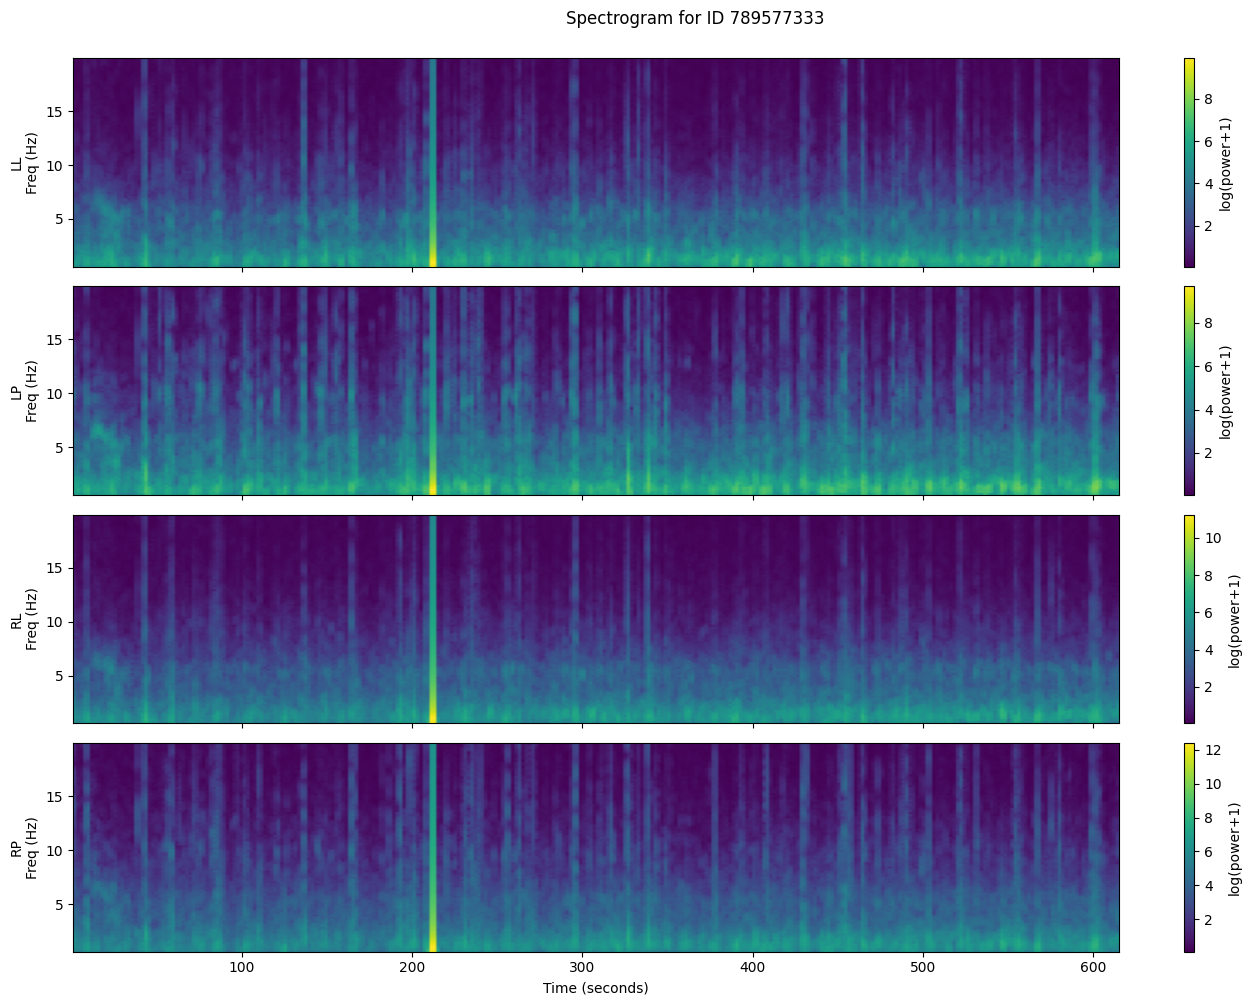

In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(regions), 1, figsize=(14, 10), sharex=True)

for ax, region in zip(axes, regions):
    region_cols = [c for c in spec_cols if c.startswith(region + '_')]
    region_freqs = [float(c.split('_')[1]) for c in region_cols]
    region_data = spec1[region_cols].T.values  # shape: (freqs, time)

    region_data_log = np.log1p(np.nan_to_num(region_data, nan=0))

    im = ax.imshow(
        region_data_log,
        aspect='auto',
        origin='lower',
        extent=[spec1['time'].iloc[0], spec1['time'].iloc[-1],
                min(region_freqs), max(region_freqs)],
        cmap='viridis',
    )
    ax.set_ylabel(f'{region}\nFreq (Hz)')
    fig.colorbar(im, ax=ax, label='log(power+1)')

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle(f'Spectrogram for ID {spectrogram_id}', y=1.0)
plt.tight_layout()
plt.show()

In [13]:
train = pd.read_csv(cons.PATH_TO_TRAIN_CSV)
this_spec = train[train['spectrogram_id'] == spectrogram_id]

print(f"Number of labeled windows for this spectrogram: {len(this_spec)}")
display(this_spec[['spectrogram_id', 'spectrogram_label_offset_seconds',
                   'expert_consensus', 'patient_id']].head())

Number of labeled windows for this spectrogram: 4


,spectrogram_id,spectrogram_label_offset_seconds,expert_consensus,patient_id
40927,789577333,0.0,Other,20654
40928,789577333,6.0,Other,20654
40929,789577333,12.0,Other,20654
40930,789577333,16.0,Other,20654
